In [1]:
#Load Data
import pandas as pd

holidays = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/holidays_events.csv")
oil = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/oil.csv")
stores = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/stores.csv")
transactions = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/transactions.csv")


test = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv")
train = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv")

In [2]:
#Convert Date
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

In [3]:
#Create Time Features
for df in [train,test]:
    df["month"] = df.date.dt.month
    df["day"] = df.date.dt.day
    df["dayofweek"] = df.date.dt.dayofweek

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train["family"] = le.fit_transform(train["family"])
test["family"] = le.transform(test["family"])

In [5]:
#Merge Store Data
train = train.merge(stores,on = "store_nbr")
test = test.merge(stores,on = "store_nbr")

In [6]:
cat_cols = ["city","state","type"]

for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 13 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       int64         
 4   sales        float64       
 5   onpromotion  int64         
 6   month        int32         
 7   day          int32         
 8   dayofweek    int32         
 9   city         int64         
 10  state        int64         
 11  type         int64         
 12  cluster      int64         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(8)
memory usage: 263.3 MB


In [8]:
#Merge Oil data
oil["date"] = pd.to_datetime(oil["date"])
oil["dcoilwtico"] = oil["dcoilwtico"].ffill()

In [9]:
train = train.merge(oil,on = "date",how="left")
test = test.merge(oil,on = "date",how="left")

In [10]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,month,day,dayofweek,city,state,type,cluster,dcoilwtico
0,0,2013-01-01,1,0,0.0,0,1,1,1,18,12,3,13,NaN
1,1,2013-01-01,1,1,0.0,0,1,1,1,18,12,3,13,NaN
2,2,2013-01-01,1,2,0.0,0,1,1,1,18,12,3,13,NaN
3,3,2013-01-01,1,3,0.0,0,1,1,1,18,12,3,13,NaN
4,4,2013-01-01,1,4,0.0,0,1,1,1,18,12,3,13,NaN


In [11]:
train["dcoilwtico"] = train["dcoilwtico"].ffill().bfill()
test["dcoilwtico"] = test["dcoilwtico"].ffill().bfill()

In [12]:
#Merge Holiday data
holidays["date"] = pd.to_datetime(holidays["date"])

holidays["is_holiday"] = (
    (holidays["type"].isin(["Holiday","Additional","Bridge"])) 
    & (~holidays["transferred"])
    ).astype(int)

holidays["is_event"] = ((holidays["type"] == "Event") & (~holidays["transferred"])).astype(int)

In [13]:
holidays_features = holidays.groupby("date").agg({"is_holiday":"max","is_event":"max"}).reset_index()

In [14]:
train = train.merge(holidays_features,on="date",how="left")
test = test.merge(holidays_features,on="date",how="left")

train[["is_holiday","is_event"]] = train[["is_holiday","is_event"]].fillna(0)
test[["is_holiday","is_event"]] = test[["is_holiday","is_event"]].fillna(0)

In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 16 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       int64         
 4   sales        float64       
 5   onpromotion  int64         
 6   month        int32         
 7   day          int32         
 8   dayofweek    int32         
 9   city         int64         
 10  state        int64         
 11  type         int64         
 12  cluster      int64         
 13  dcoilwtico   float64       
 14  is_holiday   float64       
 15  is_event     float64       
dtypes: datetime64[ns](1), float64(4), int32(3), int64(8)
memory usage: 332.0 MB


In [16]:
# Adding Lag and Rolling Features of sale

train = train.sort_values(["store_nbr","family","date"])

train["lag_1"] = train.groupby(["store_nbr","family"])["sales"].shift(1)
train["lag_2"] = train.groupby(["store_nbr","family"])["sales"].shift(2)
train["lag_7"] = train.groupby(["store_nbr","family"])["sales"].shift(7)
train["lag_14"] = train.groupby(["store_nbr","family"])["sales"].shift(14)

train["rolling_mean_7"] = train.groupby(["store_nbr","family"])["sales"].transform(
                            lambda x: x.shift(1).rolling(7).mean())
train["rolling_mean_14"] = train.groupby(["store_nbr","family"])["sales"].transform(
                            lambda x: x.shift(1).rolling(14).mean())
train["rolling_std_7"] = train.groupby(["store_nbr","family"])["sales"].transform(
                            lambda x: x.shift(1).rolling(7).std())

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000888 entries, 0 to 3000755
Data columns (total 23 columns):
 #   Column           Dtype         
---  ------           -----         
 0   id               int64         
 1   date             datetime64[ns]
 2   store_nbr        int64         
 3   family           int64         
 4   sales            float64       
 5   onpromotion      int64         
 6   month            int32         
 7   day              int32         
 8   dayofweek        int32         
 9   city             int64         
 10  state            int64         
 11  type             int64         
 12  cluster          int64         
 13  dcoilwtico       float64       
 14  is_holiday       float64       
 15  is_event         float64       
 16  lag_1            float64       
 17  lag_2            float64       
 18  lag_7            float64       
 19  lag_14           float64       
 20  rolling_mean_7   float64       
 21  rolling_mean_14  float64       
 22 

In [18]:
#Select Features
features = [
    "store_nbr",
    "family",
    "onpromotion",
    "month",
    "day",
    "dayofweek",
    "city",
    "state",
    "type",
    "cluster",
    "dcoilwtico",
    "is_holiday",
    "is_event",
    "lag_1",
    "lag_2",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_14"
]

target = "sales"

In [19]:
#Train XGBoost
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators = 1000,
    learning_rate = 0.05,
    max_depth = 8,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42
)

In [20]:
train["lag_28"] = train.groupby(["store_nbr","family"])["sales"].shift(28)
features.append("lag_28")

In [21]:
train["rolling_mean_28"] = train.groupby(["store_nbr","family"])["sales"].transform(
                            lambda x: x.shift(1).rolling(28).mean())
features.append("rolling_mean_28")

In [22]:
train["week_of_month"] = (
    (train["date"].dt.day - 1) // 7
).astype("int32")
features.append("week_of_month")

In [23]:
train["promo_last_7"] = (
    train
    .groupby(["store_nbr","family"])["onpromotion"]
    .transform(
        lambda x: x.shift(1).rolling(7,min_periods=1).sum()
    )
)
train["promo_last_14"] = (
    train
    .groupby(["store_nbr", "family"])["onpromotion"]
    .transform(
        lambda x: x.shift(1).rolling(14, min_periods=1).sum()
    )
)
train["promo_rate_14"] = (
    train["promo_last_14"] / 14
)


In [24]:
train["promo_last_7"] = train["promo_last_7"].fillna(0)
train["promo_last_14"] = train["promo_last_14"].fillna(0)
train["promo_rate_14"] = train["promo_rate_14"].fillna(0)

In [25]:
features.extend(["promo_last_7","promo_last_14","promo_rate_14"])

In [26]:
train_data = train[train.date < "2017-07-01"]
valid_data = train[train.date >= "2017-07-01"]

In [27]:
import numpy as np

train_data_log = np.log1p(train_data[target])

model.fit(train_data[features],train_data_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [28]:
#Validate

from sklearn.metrics import mean_squared_log_error

pred_log = model.predict(valid_data[features])

pred = np.expm1(pred_log)

score = mean_squared_log_error(valid_data[target],pred.clip(0))

rmsle = np.sqrt(score)

print(rmsle)

0.3713588911866129


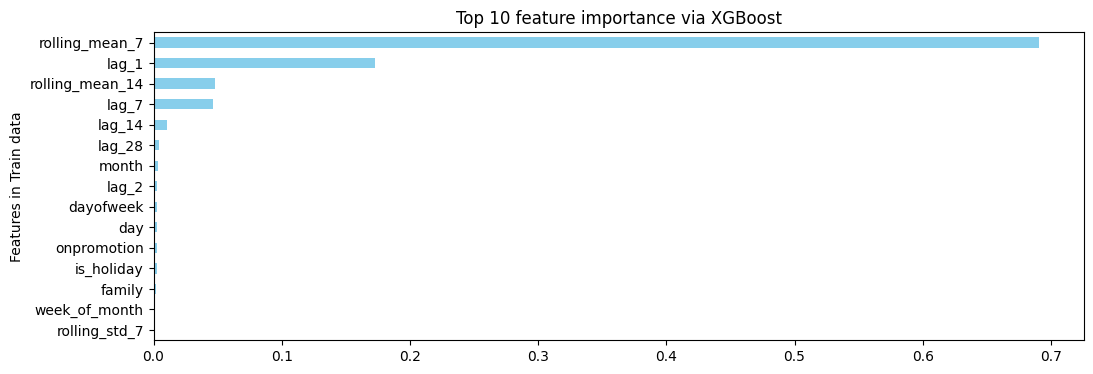

In [29]:
# Visualizing the Feature Importance
import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_series = pd.Series(importances,index = features)

top_features = feature_series.sort_values(ascending=True).tail(15)

plt.figure(figsize = (12,4))
top_features.plot(kind = "barh",color="skyblue")
plt.ylabel("Features in Train data")
plt.title("Top 10 feature importance via XGBoost")
plt.show()

In [30]:
test["week_of_month"] = (
    (test["date"].dt.day - 1) // 7
).astype("int32")

In [31]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             28512 non-null  int64         
 1   date           28512 non-null  datetime64[ns]
 2   store_nbr      28512 non-null  int64         
 3   family         28512 non-null  int64         
 4   onpromotion    28512 non-null  int64         
 5   month          28512 non-null  int32         
 6   day            28512 non-null  int32         
 7   dayofweek      28512 non-null  int32         
 8   city           28512 non-null  int64         
 9   state          28512 non-null  int64         
 10  type           28512 non-null  int64         
 11  cluster        28512 non-null  int64         
 12  dcoilwtico     28512 non-null  float64       
 13  is_holiday     28512 non-null  float64       
 14  is_event       28512 non-null  float64       
 15  week_of_month  2851

In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000888 entries, 0 to 3000755
Data columns (total 29 columns):
 #   Column           Dtype         
---  ------           -----         
 0   id               int64         
 1   date             datetime64[ns]
 2   store_nbr        int64         
 3   family           int64         
 4   sales            float64       
 5   onpromotion      int64         
 6   month            int32         
 7   day              int32         
 8   dayofweek        int32         
 9   city             int64         
 10  state            int64         
 11  type             int64         
 12  cluster          int64         
 13  dcoilwtico       float64       
 14  is_holiday       float64       
 15  is_event         float64       
 16  lag_1            float64       
 17  lag_2            float64       
 18  lag_7            float64       
 19  lag_14           float64       
 20  rolling_mean_7   float64       
 21  rolling_mean_14  float64       
 22 

In [33]:
# Train Final model using the full train and test data

#Creat History
history = train[["date","store_nbr","family","sales","onpromotion"]].copy()

#Sort test
test = test.sort_values(["date","store_nbr","family"])

In [34]:
#Prediction Loop

predictions = []

for current_date in sorted(test["date"].unique()):

    current_day = test[
        test["date"] == current_date
    ].copy()

    history = history.sort_values("date")

    # Create Lag features

    lag_features = (
        history
        .groupby(["store_nbr","family"])
        .agg(
            lag_1 = ("sales" , lambda x: x.iloc[-1]),
            lag_2 = ("sales" , lambda x: x.iloc[-2]),
            lag_7 = ("sales" , lambda x: x.iloc[-7]),
            lag_14 = ("sales" , lambda x: x.iloc[-14]),
            lag_28 = ("sales" , lambda x: x.iloc[-28]),

            rolling_mean_7 = (
                "sales",
                lambda x: x.tail(7).mean()
            ),
            rolling_mean_14 = (
                "sales",
                lambda x: x.tail(14).mean()
            ),
            rolling_std_7 = (
                "sales",
                lambda x: x.tail(7).std()
            ),
            rolling_mean_28 = (
                "sales",
                lambda x: x.tail(28).mean()
            )
        )
        .reset_index()
    )

    # Merge into current day

    current_day = current_day.merge(
        lag_features,
        on = ["store_nbr","family"],
        how = "left"
    )

    #Filling remaining NaNs

    current_day["rolling_std_7"] = current_day["rolling_std_7"].fillna(0)

    #Promotion Features

    promo_features = (
        history
        .groupby(["store_nbr","family"])
        .agg(
            promo_last_7=(
                "onpromotion",
                lambda x: x.tail(7).sum()
            ),
            promo_last_14=(
                "onpromotion",
                lambda x: x.tail(14).sum()
            ),
            promo_rate_14 = (
                "onpromotion",
                lambda x: x.tail(14).sum() / 14
            )
        )
        .reset_index()
    )

    current_day = current_day.merge(
        promo_features,
        on=["store_nbr","family"],
        how="left"
    )

    current_day["promo_last_7"] = (
        current_day["promo_last_7"].fillna(0)
    )

    current_day["promo_last_14"] = (
        current_day["promo_last_14"].fillna(0)
    )

    
    # Predict
    pred_log = model.predict(current_day[features])
    pred = np.expm1(pred_log)
    pred = np.clip(pred,0,None)

    # Store Prediction

    current_day["sales"] = pred
    predictions.append(current_day[["id","sales"]])

    # Update History

    history = pd.concat([
        history,
        current_day[
            ["date","store_nbr","family","sales","onpromotion"]
        ]
    ])

In [35]:
# Build submission
submission = pd.concat(
    predictions,
    ignore_index=True
)


In [36]:
# Save

submission.to_csv(
    "submission.csv",
    index=False
)


In [37]:
submission.shape

(28512, 2)